In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('penguins').dropna()
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [32]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


In [33]:
df_adelie = df[df['species'] == 'Adelie']
df_adelie

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
147,Adelie,Dream,36.6,18.4,184.0,3475.0,Female
148,Adelie,Dream,36.0,17.8,195.0,3450.0,Female
149,Adelie,Dream,37.8,18.1,193.0,3750.0,Male
150,Adelie,Dream,36.0,17.1,187.0,3700.0,Female


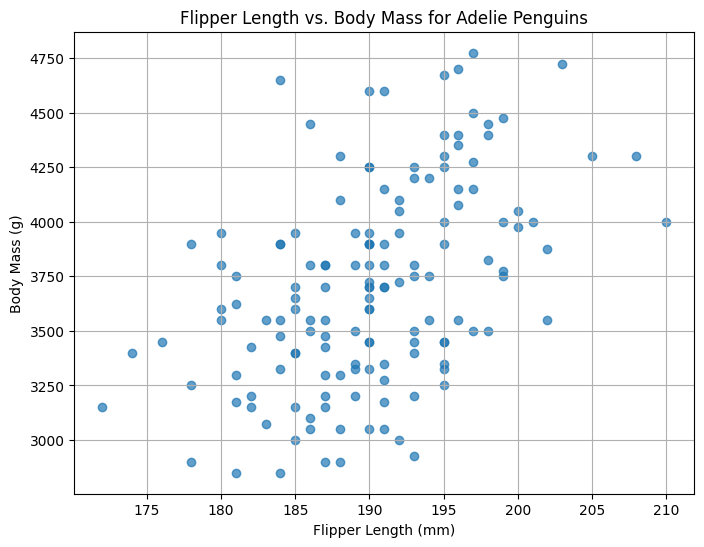

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(df_adelie['flipper_length_mm'], df_adelie['body_mass_g'], alpha=0.7)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs. Body Mass for Adelie Penguins')
plt.grid(True)
plt.show()

In [45]:
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']]
y = df['body_mass_g'].values.reshape(-1,1)

# CREAMOS RED NEURONAL PARA PREDECIR EL PESO DE PINGUINO

## PASO 1 - IMPORTAMOS LIBRERIAS NECESARIAS

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input

## PASO 2 - ESCALAMOS DATOS

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y)

## PASO 3 - DIVIDAMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

## PASO 4 - CREAMOS LA RED NEURONAL

In [49]:
red = Sequential()
inputs = Input(shape=(3,))
entrada = Dense(units=3,activation='relu')
oculta1 = Dense(units=64,activation='relu')
oculta2 = Dense(units=32,activation='relu')
salida = Dense(units=1,activation='relu')

red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red

<Sequential name=sequential_4, built=False>

## PASO 5- COMPILAMOS LA RED

In [50]:
red.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

## PASO 6 - ENTRENAMOS LA RED NEURONAL

In [53]:
history = red.fit(X_train,y_train,epochs=50,batch_size=128,validation_split=0.2,validation_data=(X_test,y_test))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7399 - mae: 0.7247 - val_loss: 0.6393 - val_mae: 0.6784
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6762 - mae: 0.6913 - val_loss: 0.5928 - val_mae: 0.6486
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.6466 - mae: 0.6795 - val_loss: 0.5586 - val_mae: 0.6296
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6013 - mae: 0.6457 - val_loss: 0.5361 - val_mae: 0.6168
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5450 - mae: 0.6093 - val_loss: 0.5259 - val_mae: 0.6086
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5771 - mae: 0.6331 - val_loss: 0.5262 - val_mae: 0.6063
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5940 - mae: 0.6454 - val_loss: 0.5301 - val_mae: 0.6105
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5659 - mae: 0.6327 - val_loss: 0.5310 - val_mae: 0.6120
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5720 - mae: 0.6297 - 

# EVALUAMOS LA RED

In [54]:
loss, mae = red.evaluate(X_test, y_test, verbose=0)
print(f'loss evaluate : {loss}')
print(f' mae evaluate : {mae}')

loss evaluate : 0.4912906587123871
 mae evaluate : 0.5704838633537292


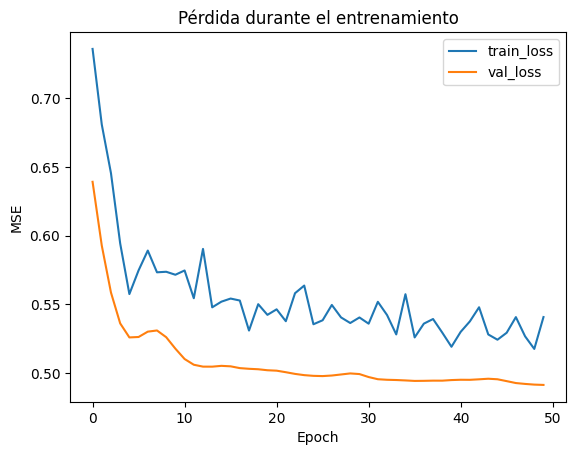

In [55]:
# 📈 Gráfico de pérdida
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


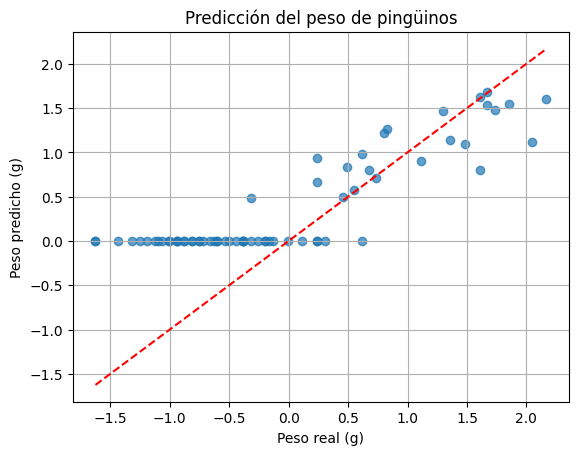

In [56]:
# 🔍 Predicciones
y_pred = red.predict(X_test).flatten()

# 📉 Comparar predicción vs valor real
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Peso real (g)')
plt.ylabel('Peso predicho (g)')
plt.title('Predicción del peso de pingüinos')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.grid(True)
plt.show()